In [89]:
# !pip install pyts
# !pip install dtaidistance
!pip install dtaidistance
!pip install pyts

# Домашнее задание

1. Генерим 21 сигналов (временных рядов), 3 класса по 7 образцов в каждом.
Постарайтесь сделать их как можно более похожими, и в тоже время различными.

1. Рассчитываем расстояние между ними по формуле Евклида и с помощью DTW

1. Описываем кратко полученные значения

1. Формируем из нагенеренных временных рядов набор данных для обучения

1. Разбиваем набор на train и test

1. Обучаем  классификаторы KNN с DTW, KNN со стандартной метрикой расстояния, TimeSeriesForest

1. Описываем кратко полученные результаты

In [90]:
import matplotlib.pyplot as plt
import numpy as np

Генерация сигнала

1 тип - гармонический (косинус)

2 тип - модифицированный синус

3 тип - пульс - сигнал

Для выполнения дз надо нагенерить 21 сигнал, по 7 сигналов каждого типа

In [91]:
def pulse(t):
    """Пульс сигнал"""
    return 1 * (abs(t) < 0.5)

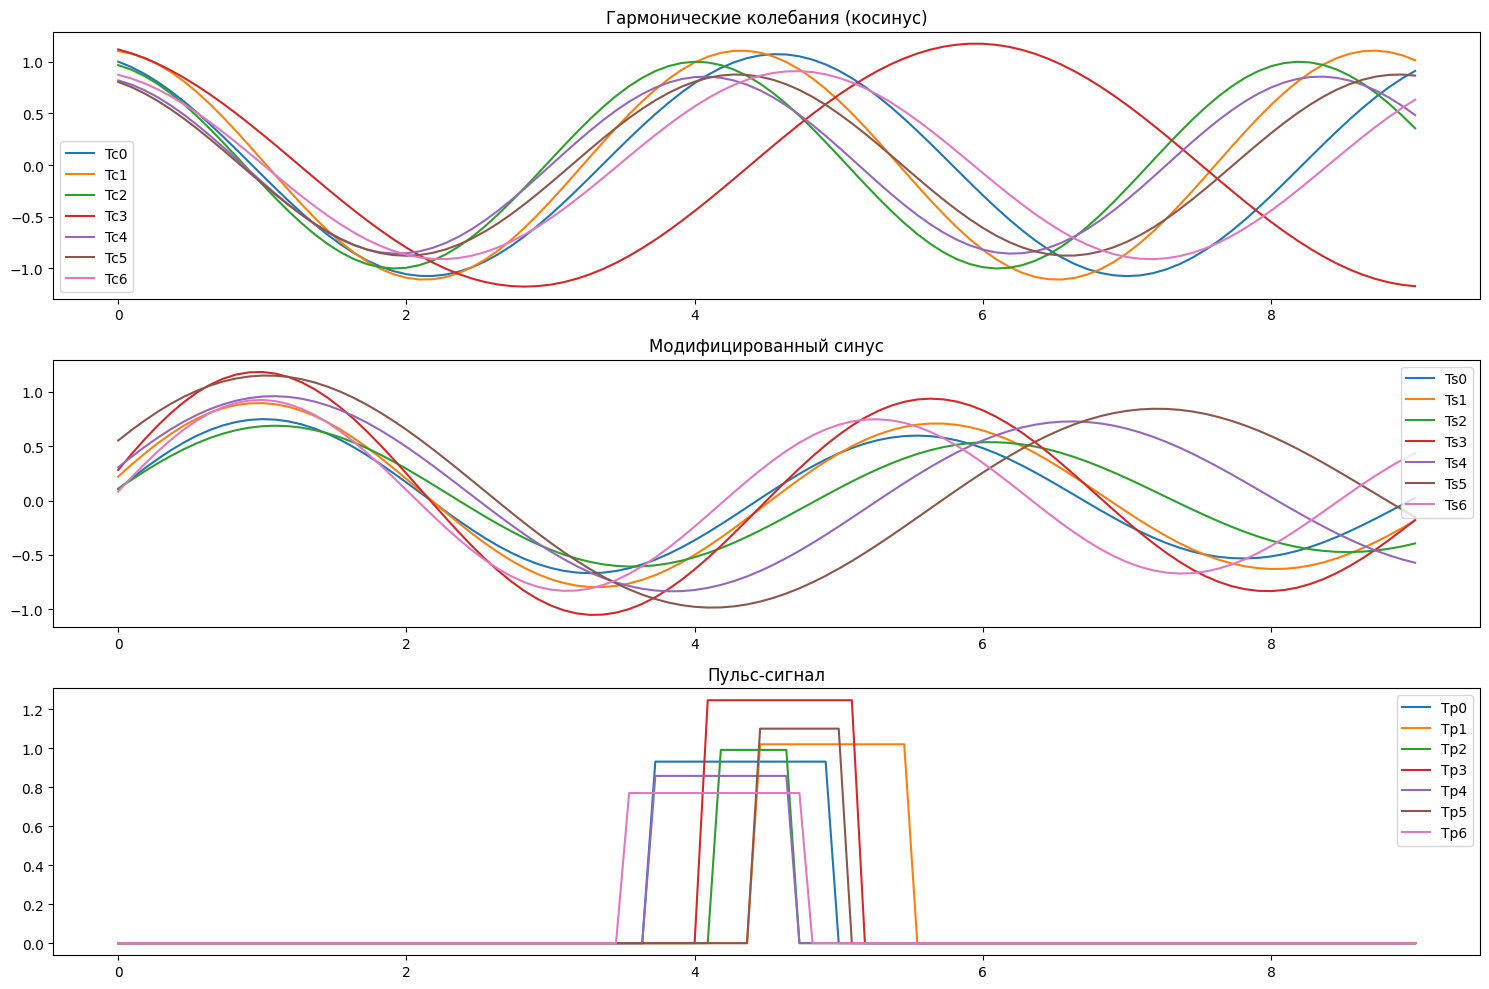

In [92]:
# индекс и отсчет времени в секундах
time_index = np.linspace(0, 9, 100)

tseries_list = {'Time': time_index}
d = np.random.random(size=10)


N = 7 #количество образцов в каждом типе сигналов


# гармонические колебания
f0 = 0.2

for i in range(N):
    freq = f0 + np.random.uniform(-0.05, 0.05)
    amp = 1 + np.random.uniform(-0.3, 0.3)
    phase = np.random.uniform(0, 0.5)
    tseries_list["Tc"+str(i)] = amp * np.cos(2 * np.pi * freq * time_index + phase)

# модифицированный синус
for i in range(N):
    freq = f0 + np.random.uniform(-0.05, 0.05)
    amp = 1 + np.random.uniform(-0.3, 0.3)
    phase = np.random.uniform(0, 0.5)
    tseries_list["Ts"+str(i)] = amp * np.sin(2 * np.pi * freq * time_index + phase) * np.exp(-0.05 * time_index)

# пульс сигнал
for i in range(N):
    shift = np.random.uniform(-0.5, 0.5)
    amp = 1 + np.random.uniform(-0.3, 0.3)
    width = np.random.uniform(0.3, 0.7)
    tseries_list["Tp"+str(i)] = amp * (np.abs(time_index - 4.5 + shift) < width).astype(float)

# отрисовка всех сигналов
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

for i in range(N):
    axes[0].plot(time_index, tseries_list["Tc"+str(i)], label=f"Tc{i}")
axes[0].set_title('Гармонические колебания (косинус)')
axes[0].legend()

for i in range(N):
    axes[1].plot(time_index, tseries_list["Ts"+str(i)], label=f"Ts{i}")
axes[1].set_title('Модифицированный синус')
axes[1].legend()

for i in range(N):
    axes[2].plot(time_index, tseries_list["Tp"+str(i)], label=f"Tp{i}")
axes[2].set_title('Пульс-сигнал')
axes[2].legend()

plt.tight_layout()
plt.show()

# Понимание Динамическое искажение (деформация) времени (Dynamic time warping, DTW)

DTW - это метод, который вычисляет оптимальное соответствие между двумя заданными последовательностями (например, временными рядами) с определенными ограничениями и правилами:

1. Каждый индекс из первой последовательности должен быть сопоставлен с одним или несколькими индексами из другой последовательности и наоборот

1. Первый индекс из первой последовательности должен совпадать с первым индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Последний индекс из первой последовательности должен совпадать с последним индексом из другой последовательности (но это не обязательно должно быть его единственным совпадением)

1. Отображение индексов из первой последовательности на индексы из другой последовательности должно монотонно возрастать, и наоборот, т. е. если j>i являются индексами из первой последовательности, то в другой последовательности не должно быть двух индексов l> k, так что индекс i совпадает с индексом l, а индекс j - с индексом k, и наоборот.

Рассмотрим два временных ряда $x$ и $x^{\prime}$ соответствующей длины n и m. Предполагается, что все элементы этих рядов лежат в одном и том же  p - одномерном пространство и точные временные метки, в которые происходят наблюдения, не принимаются во внимание, важен только их порядок.

Более формально задача оптимизации записывается в виде:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left( \sum_{(i, j) \in \pi} d(x_i, x^\prime_j)^q \right)^{\frac{1}{q}}
$


Здесь путь выравнивания $\pi$  длины K  представляет собой последовательность K  пары индексов $((i_0,j_0),..,(i_{K-1},j_{K-1}))$
 и  $A(x,x^{\prime})$
 представляет собой набор всех допустимых путей. Чтобы считаться допустимым, путь должен удовлетворять следующим условиям:

Начало (соответственно, конец) временных рядов сопоставляются друг с другом:

$
\pi_0 = (0, 0)
$

$
\pi_{K-1} = (n - 1, m - 1)
$

Последовательность монотонно увеличивается в обоих $i$ и $j$  и все индексы временных рядов должны отображаться хотя бы один раз, что может быть записано как:

$
i_{k-1} \leq i_k \leq i_{k-1} + 1
$

$
j_{k-1} \leq j_k \leq j_{k-1} + 1
$


Другим способом представления  DTW является использование двоичной матрицы, ненулевые элементы которой соответствуют совпадениям между элементами временного ряда. Это представление связано с представлением последовательности индексов, использованным выше:

$
\begin{equation}
(A_\pi)_{i,j} = \left\{ \begin{array}{rl} 1 & \text{ if } (i, j) \in \pi \\
                                      0 & \text{ otherwise}
                        \end{array} \right. \,\,\,\,\,\,\, .
\end{equation}
$

Тогда  DTW может быть выражено через скалярные произведения следующим образом:

$
DTW_q({x}, {x}^\prime) =
    \min_{\pi \in \mathcal{A}({x}, {x}^\prime)}
        \left\langle A_\pi,  D_q({x}, {x}^\prime) \right\rangle^{\frac{1}{q}}
 $

Решение поставленной задачи оптимизации может быть найдено с помощью динамического программирования.
Обозначим:

$
R_{i,j} = DTW_q({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})^q
$

где ${x}_{\rightarrow i}$ - обозначает наблюдение ряда до отметки i

Тогда получаем реккурентную формулу:

$
\begin{aligned}
R_{i,j}
    &= \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
        \sum_{(k, l) \in \pi} d(x_k, x^\prime_l)^q \\
    &\stackrel{*}{=} d(x_i, x^\prime_j)^q +
        \min_{\pi \in \mathcal{A}({x}_{\rightarrow i}, {x}^\prime_{\rightarrow j})}
            \sum_{(k, l) \in \pi[:-1]} d(x_k, x^\prime_l)^q \\
    &\stackrel{**}{=} d(x_i, x^\prime_j)^q +
        \min ({\color{Blue}R_{i-1, j}}, {\color{Red}R_{i, j-1}}, {\color{ForestGreen}R_{i-1, j-1}})
\end{aligned}
$

\* - потому, что последний элемент на допустимом пути должен соответствовать последним элементам ряда.

** - результат условий смежности допустимых путей.

In [93]:
def distance_matrix(x, y, q) -> np.array:
    """
    Функция  рассчета  матрицы  расстояний между точками двух рядов
    """
    mdist = np.zeros((len(y), len(x)))
    for i in range(len(y)):
        for j in range(len(x)):
            mdist[i][j] = abs(x[j] - y[i]) ** q
    return mdist

In [94]:
# Посчитаем DTW для двух временных рядов
# Сначала напишем функцию, которая это все вычисляет


def DTW(x, x_s, q=1, isDTW=True):
    '''
        x: первый ряд
        x_s : второй ряд
        q : степень для вычисления базового расстояния
    '''
    N = len(x) # Считаем, что ряды равной длины. Но это не всегда так, перепишите функцию для
               # вычисления расстояния между рядами, длины которых не равны

    # Строим матрицу согласно реккурентной формуле, полученной выше. Матрица в нашем случае будет размерности

    dist = distance_matrix(x,x_s,q=2)

    R = [[0] * (N+1) for i in range(N+1)]

    for i in range(1,N):
        R[i][0] = dist[i,0] + R[i-1][0]
        R[0][i] = dist[0,i] + R[0][i-1]

    # проверяем, что записалось
    #print("Начинаем заполнять матрицу R")
    #for i in range(N+1):
    #    print(R[i])

    k = 0
    if isDTW:
        k = 1

    # начинаем расчет по реккурентной формуле

    for i in range(1,N+1):
        for j in range(1,N+1):
            R[i][j] = dist[min(i, N-1)][min(j, N-1)] + min(
                R[i-1][j]   * k,     # вставка (только для DTW)
                R[i][j-1]   * k,     # удаление (только для DTW)
                R[i-1][j-1]          # совпадение (диагональ)
            )
    # проверяем, что записалось
    # print("\nпосле заполнения матрицы R")
    #for i in range(N+1):
    #    print(R[i])

    # ищем минимальный путь. Начинаем от нижнего правого угла.
    pth = []   # лист с кортежами индексов пути
    i = N
    j = N
    while i >= 0 and j >= 0:
        pth.append((i,j))
        if R[i][j-1] <= R[i-1][j-1] and R[i][j-1] <= R[i-1][j]:
            I = i
            J = j-1

        if R[i-1][j] <= R[i-1][j-1] and R[i-1][j] <= R[i][j-1]:
            I = i - 1
            J = j

        if R[i-1][j-1] <= R[i][j-1] and R[i-1][j-1] <= R[i-1][j]:
            I = i - 1
            J = j - 1

        i = I
        j = J


    #print("\nПуть:")
    #print(pth)

    #Считаем расстояние между двумя рядами
    s = 0
    for l in pth:
        s += R[l[0]][l[1]]
    s = s/len(pth)

    return s, pth, R


In [95]:
# Посчитаем DTW для двух временных рядов

#для простоты выделяем ряды, которые будем сравнивать
x = np.abs(tseries_list.get("Ts1", np.zeros(100))) # Если tseries_list не заполнен
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))
x_p = np.abs(tseries_list.get("Tp2", np.zeros(100)))

s1 = DTW(x, x_s, q=2)
s2 = DTW(x, x_p, q=2)

# print (f"DTW\nTs1 и Ts3 = {s1[0]}     Ts1 и Tp1 = {s2[0]}")

s11 = DTW(x, x_s, q=2, isDTW=False)
s21 = DTW(x, x_p, q=2, isDTW=False)

# print (f"Dec\nTs1 и Ts3 = {s11[0]}     Ts1 и Tp1 = {s21[0]}")

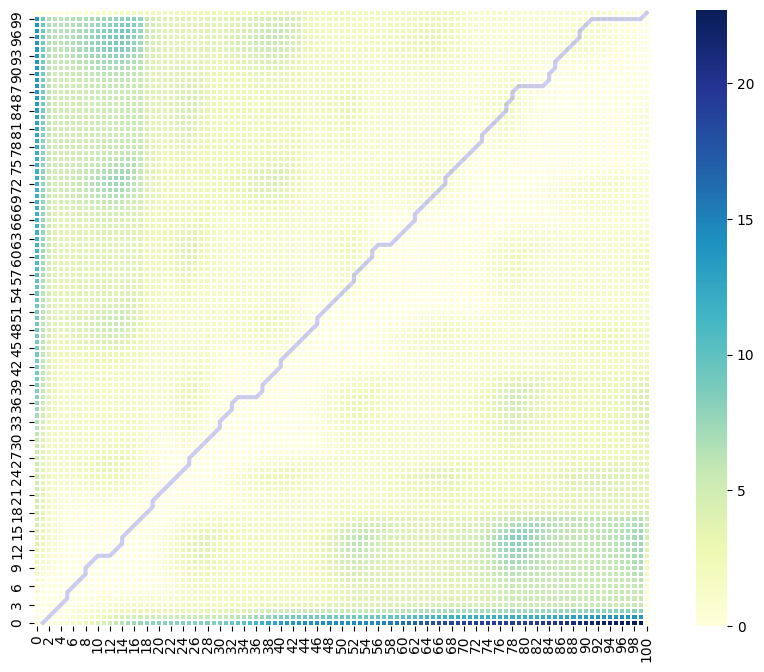

In [96]:
import seaborn as sbn
# Отрисуем матрицы весов расстояний Ts1 и Ts3

cost_matrix = s1[2]
warp_path = s1[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

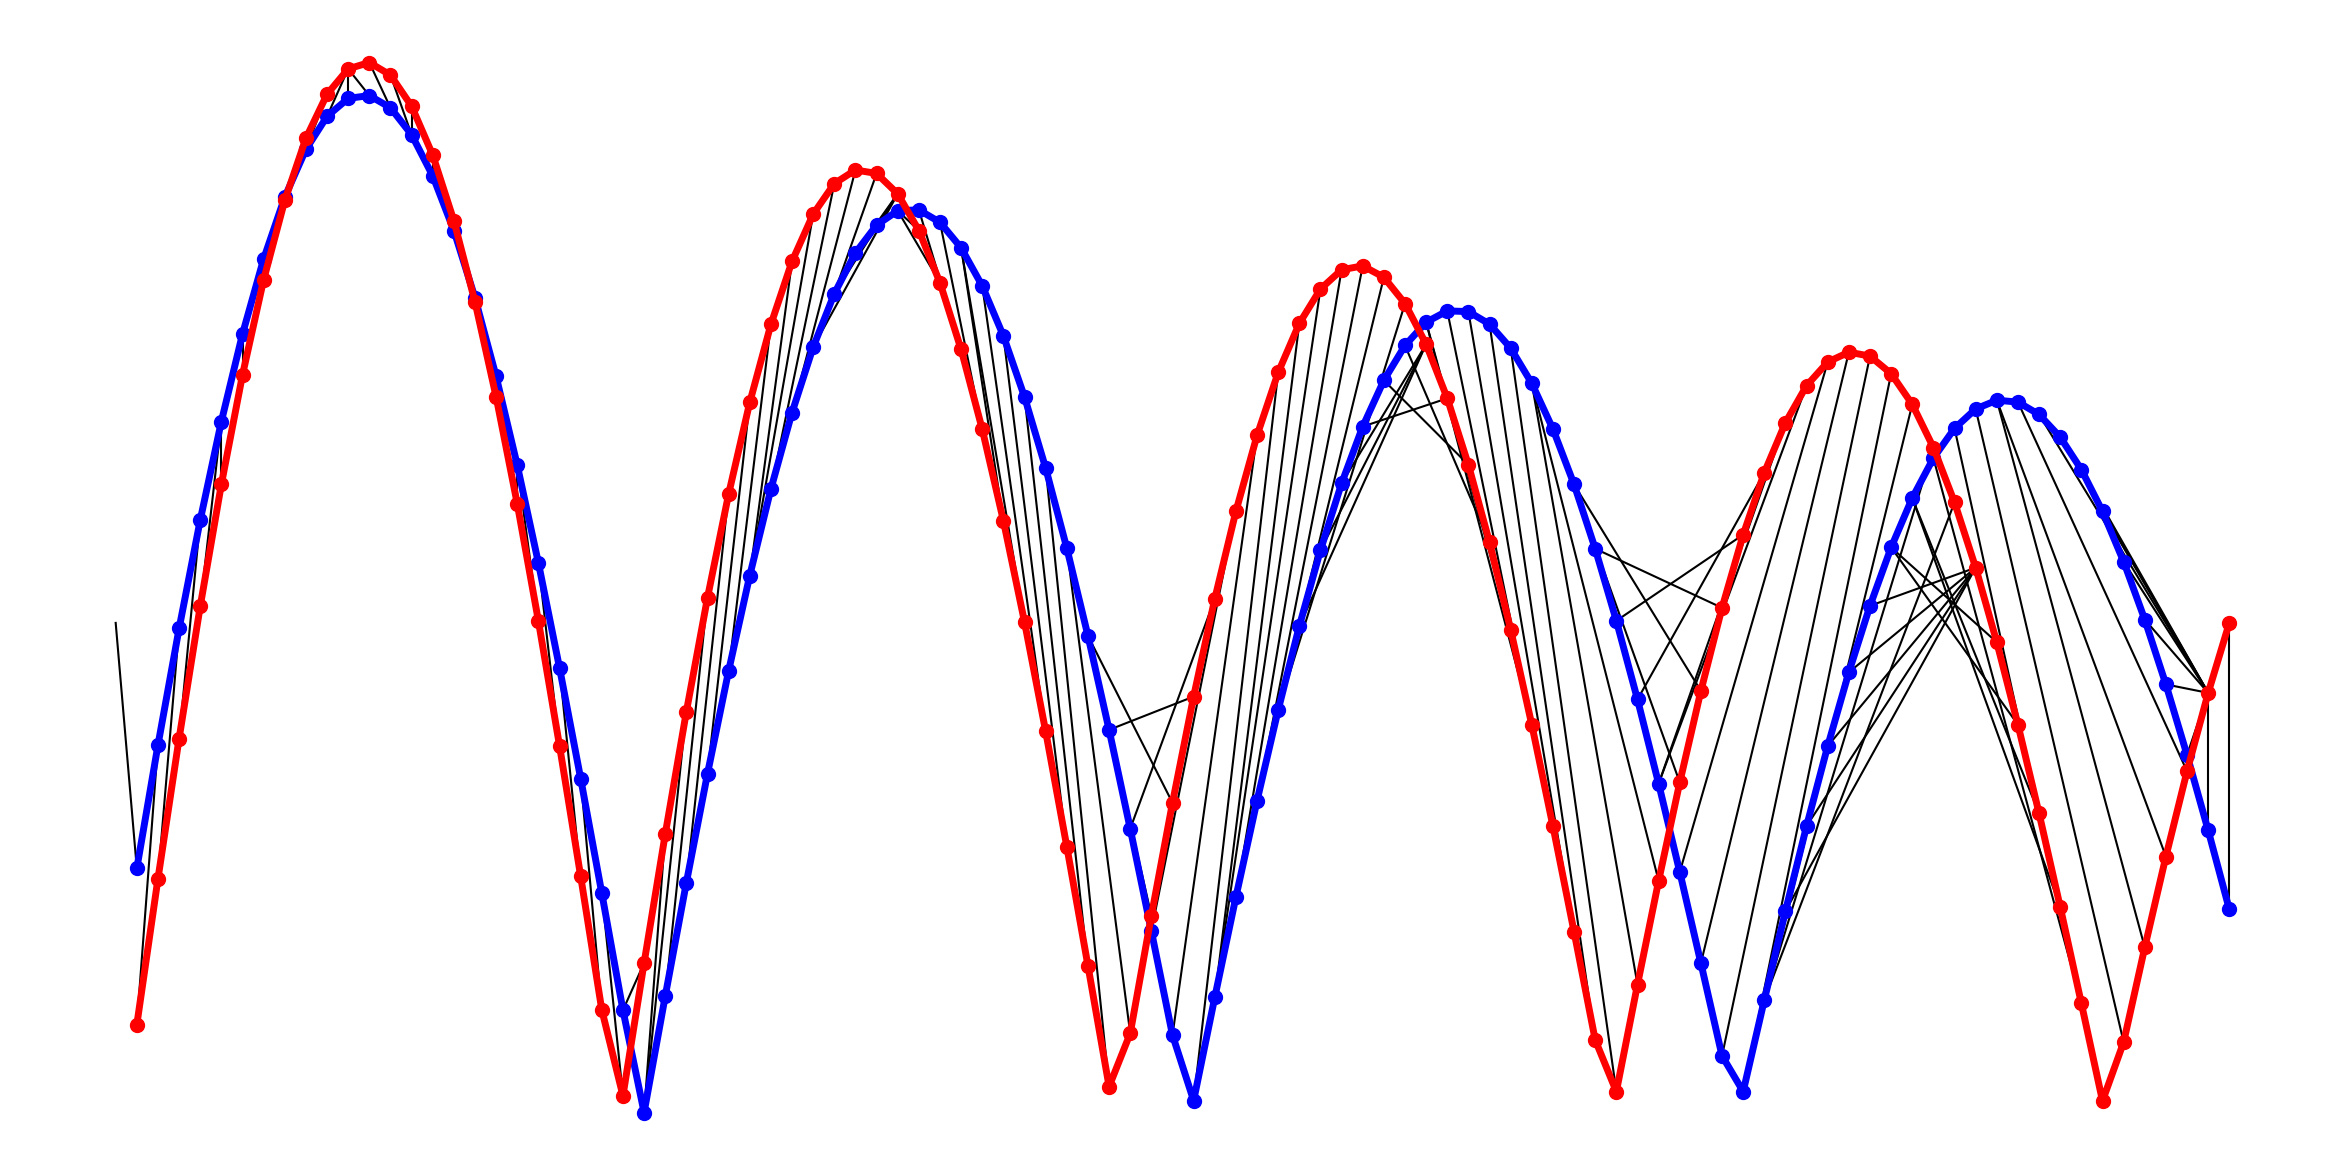

In [97]:
fig, ax = plt.subplots(figsize=(30, 15))


warp_path = s1[1]
x1 = x
x2 = x_s

# Remove the border and axes ticks
fig.patch.set_visible(True)
ax.axis('off')

for [map_x, map_y] in warp_path:
    ax.set_facecolor('white')
    ax.plot([map_x-1, map_y-1], [x1[map_x-1], x2[map_y-1]], '-k')

ax.plot(x1, color='blue', marker='o', markersize=10, linewidth=5)
ax.plot(x2, color='red', marker='o', markersize=10, linewidth=5)
ax.tick_params(axis="both", which="major", labelsize=18)

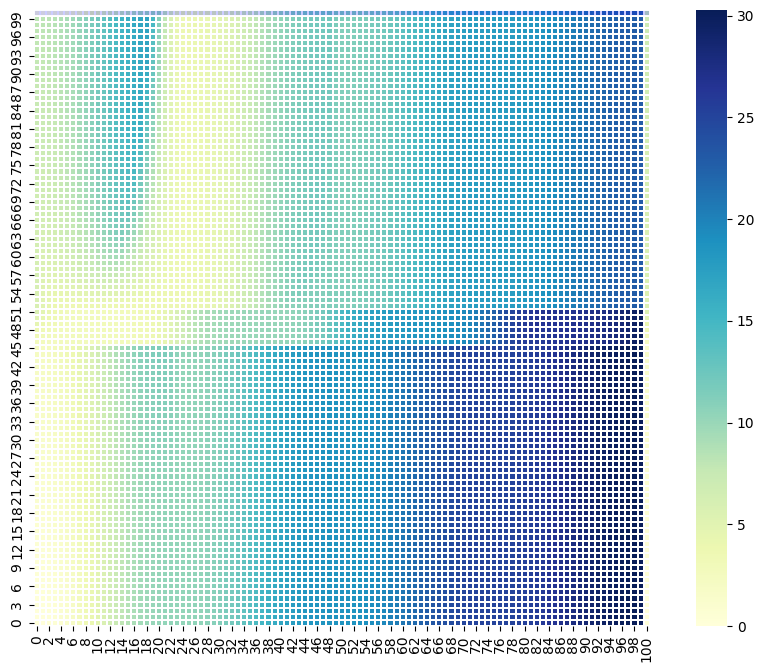

In [98]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1

cost_matrix = s2[2]
warp_path = s2[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

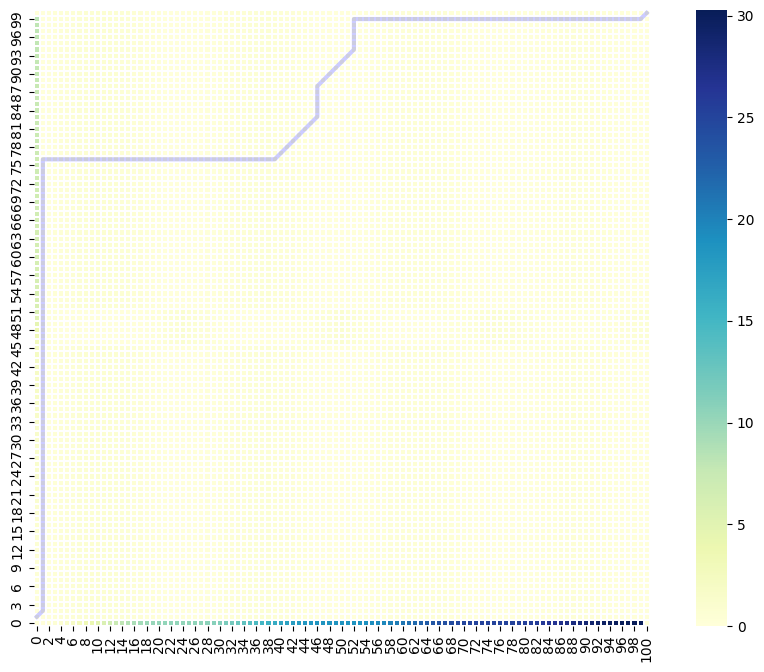

In [99]:
# Отрисуем матрицы весов расстояний Ts1 и Tp1 без DTW

cost_matrix = s21[2]
warp_path = s21[1]

fig, ax = plt.subplots(figsize=(12, 8))
ax = sbn.heatmap(cost_matrix, square=True, linewidths=0.1, cmap="YlGnBu", ax=ax)
ax.invert_yaxis()


path_x = [p[0] for p in warp_path]
path_y = [p[1] for p in warp_path]

# Align the path from the center of each cell
path_xx = [x+0.5 for x in path_x]
path_yy = [y+0.5 for y in path_y]

ax.plot(path_xx, path_yy, color='blue', linewidth=3, alpha=0.2)

А теперь попробуем вычислить тоже самое, но с помощью встроенных функций Python

In [100]:
from dtaidistance import dtw

x = np.abs(tseries_list.get("Ts1", np.zeros(100)))
x_s = np.abs(tseries_list.get("Ts6", np.zeros(100)))

distance, paths = dtw.warping_paths(x, x_s)
print(f"DTW distance (dtaidistance): {distance}")

DTW distance (dtaidistance): 0.4940261448739312


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

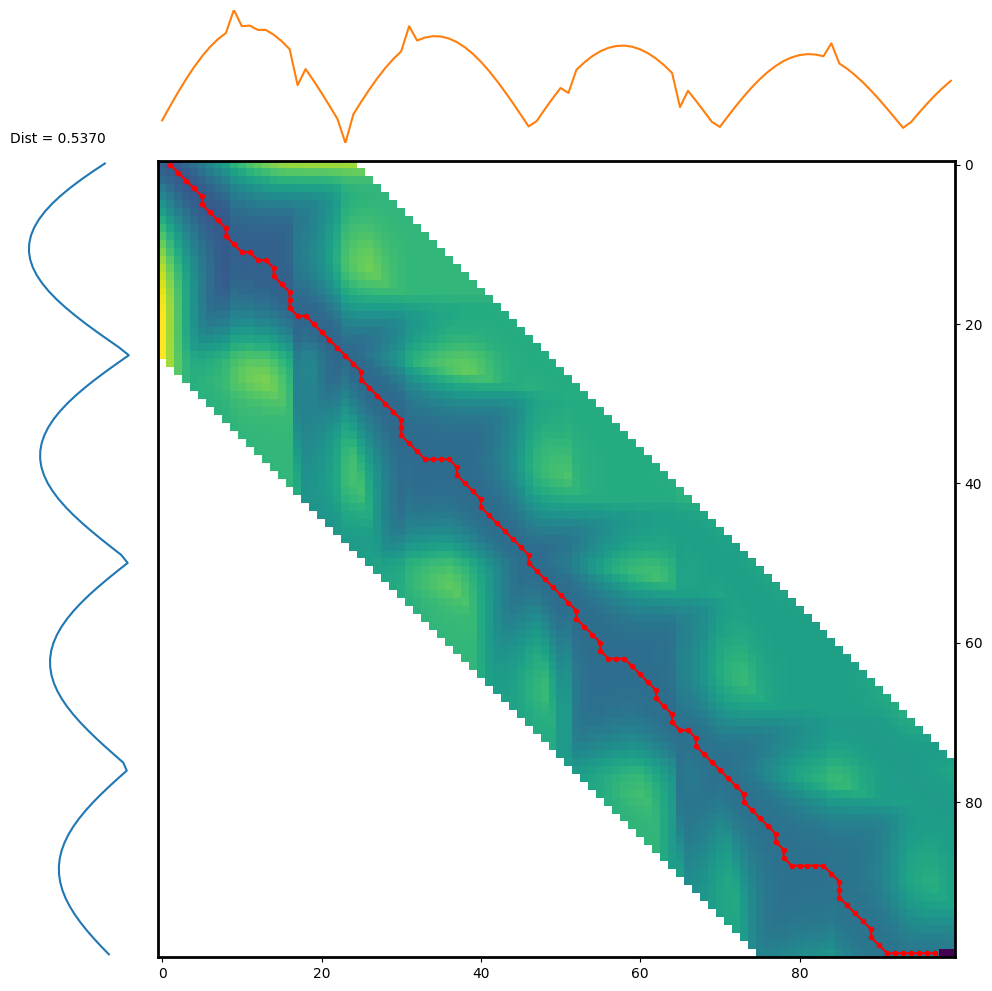

In [101]:
import random
import numpy as np
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

# Задаем рабочие наборы данных
sequence_1 = x
sequence_2 = x_s

# Вносим небольшие случайные искажения
random.seed(1)
for idx in range(len(sequence_2)):
    if random.random() < 0.05:
        sequence_2[idx] += (random.random() - 0.5) / 2

# Вычисляем dtw-метрики и строим матрицу переходов
total_dist, paths_matrix = dtw.warping_paths(sequence_1, sequence_2, window=25, psi=2)
shortest_path = dtw.best_path(paths_matrix)

# Корректный вызов отрисовки со всеми необходимыми структурами данных
dtwvis.plot_warpingpaths(
    s1=sequence_1,
    s2=sequence_2,
    paths=paths_matrix,
    cost_matrix=paths_matrix,
    path=shortest_path
)

In [102]:
x = np.abs(tseries_list["Ts1"])
x_p = np.abs(tseries_list["Tp2"])


distance, paths = dtw.warping_paths(x, x_p)
print(distance)
print(paths)

4.793633115690735
[[0.                inf        inf ...        inf        inf        inf]
 [       inf 0.22054069 0.31189164 ... 2.83504242 2.84360752 2.85214689]
 [       inf 0.39571139 0.39571139 ... 2.84548355 2.85401731 2.86252564]
 ...
 [       inf 5.49916312 5.49916312 ... 4.783342   4.783342   4.783342  ]
 [       inf 5.50501937 5.50501937 ... 4.79007347 4.79007347 4.79007347]
 [       inf 5.508117   5.508117   ... 4.79363312 4.79363312 4.79363312]]


(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

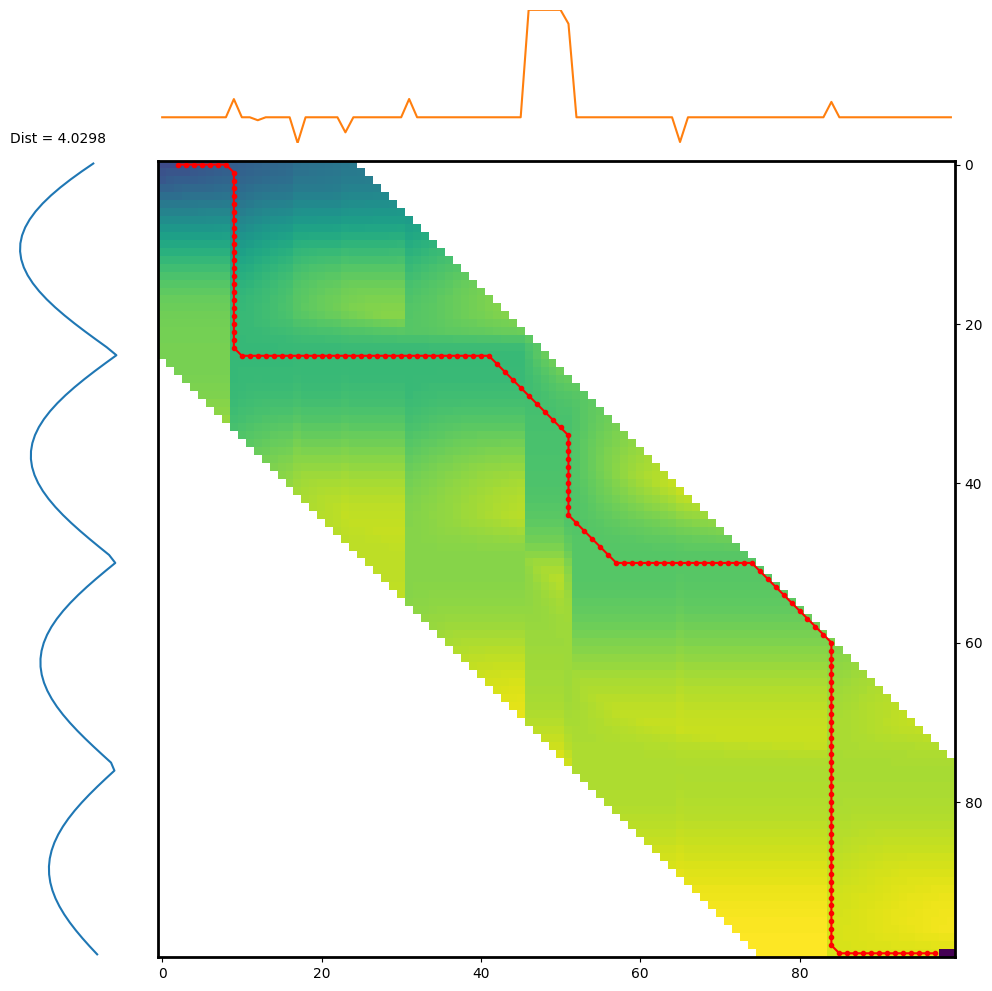

In [103]:
import random
import numpy as np
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis

# Определяем исходные временные ряды
time_series_a = x
time_series_b = x_p

# Добавляем случайный шум в целевой ряд
random.seed(1)
for i in range(len(time_series_b)):
    if random.random() < 0.05:
        time_series_b[i] += (random.random() - 0.5) / 2

# Расчет путей трансформации времени
distance_val, matrix_paths = dtw.warping_paths(time_series_a, time_series_b, window=25, psi=2)
optimal_route = dtw.best_path(matrix_paths)

# Корректное сопоставление аргументов для функции визуализации
dtwvis.plot_warpingpaths(
    s1=time_series_a,
    s2=time_series_b,
    paths=matrix_paths,
    cost_matrix=matrix_paths,
    path=optimal_route
)

In [104]:
# переделываем датасет так, чтобы с ним можно было бы работать

x = []  #значения
Y = []  # целевая переменная

for v in tseries_list:
    if v!= 'Time':
        x.append(tseries_list[v])
        c = v[:-1]
        if c == "Ts":
            Y.append(0)
        elif c == "Tc":
            Y.append(1)
        else: Y.append(2)


arr = np.arange(len(Y))
np.random.shuffle(arr)


print(Y)

X_train = []
X_test = []
y_train = []
y_test = []

# разделение на обучающую и тестовую выборки (последние 5 элементов уходят в тест)
split_bound = len(arr) - 5
train_indices = arr[:split_bound]
test_indices = arr[split_bound:]

# формирование тренировочных наборов данных
for index in train_indices:
    X_train.append(x[index])
    y_train.append(Y[index])

# формирование тестовых наборов данных
for index in test_indices:
    X_test.append(x[index])
    y_test.append(Y[index])

# приведение списков к массивам numpy
X_train = np.array(X_train)
X_test = np.array(X_test)
y_train = np.array(y_train)
y_test = np.array(y_test)

print(f'Train: {len(X_train)}, Test: {len(X_test)}')
print(f'y_train: {y_train}')
print(f'y_test: {y_test}')

[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2]
Train: 16, Test: 5
y_train: [2 1 2 2 1 2 0 1 0 1 1 0 1 0 1 2]
y_test: [0 2 2 0 0]


In [105]:
from pyts.classification import KNeighborsClassifier

# Создаем экземпляр классификатора с метрикой DTW
dtw_knn_model = KNeighborsClassifier(metric='dtw')

# Запускаем обучение на тренировочных данных
dtw_knn_model.fit(X_train, y_train)

# Считаем итоговую точность модели
total_accuracy = dtw_knn_model.score(X_test, y_test)
print(f"KNN (DTW) Accuracy: {total_accuracy}")

# Выделяем тестовый паттерн для предсказания вероятностей
target_pattern = X_test[2].reshape(1, -1)
probabilities_vec = dtw_knn_model.predict_proba(target_pattern)

print(f"Вектор вероятности принадлежности к классам: {probabilities_vec}")
print(f"Истинный класс для предсказаний: {y_test[2]}")

KNN (DTW) Accuracy: 1.0
Вектор вероятности принадлежности к классам: [[0. 0. 1.]]
Истинный класс для предсказаний: 2


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12

In [106]:
import numpy as np
from pyts.classification import TimeSeriesForest
import matplotlib.pyplot as plt



# Запуск обучения модели TimeSeriesForest
clf = TimeSeriesForest(random_state=43)
clf.fit(X_train, y_train)

# Валидация точности на тестовом сплите
model_accuracy = clf.score(X_test, y_test)
print(f"TimeSeriesForest Accuracy: {model_accuracy}")

# Проверка распределения вероятностей классов для выбранного экземпляра
target_sample = X_test[2].reshape(1, -1)
predicted_probs = clf.predict_proba(target_sample)

print(f"Вектор вероятности принадлежности к классам: {predicted_probs}")
print(f"Истинный класс для предсказаний: {y_test[2]}")

TimeSeriesForest Accuracy: 1.0
Вектор вероятности принадлежности к классам: [[0.058 0.042 0.9  ]]
Истинный класс для предсказаний: 2


In [107]:
from pyts.classification import KNeighborsClassifier

# Настройка и запуск KNN классификатора со стандартной евклидовой метрикой
knn_euclidean = KNeighborsClassifier(metric='euclidean')
knn_euclidean.fit(X_train, y_train)

# Подсчет точности евклидовой модели
eucl_accuracy = knn_euclidean.score(X_test, y_test)
print(f"KNN (Euclidean) Accuracy: {eucl_accuracy}")

# Анализ предсказаний и истинных меток на конкретном примере
eval_sample = X_test[2].reshape(1, -1)
probs_vector = knn_euclidean.predict_proba(eval_sample)

print(f"Вектор вероятности принадлежности к классам: {probs_vector}")
print(f"Истинный класс для предсказаний: {y_test[2]}")
print()

# Вывод сводной таблицы по двум подходам
print('=== Сравнение результатов ===')
# Проверяем наличие базовой модели в контексте для безопасного извлечения скора
dtw_accuracy = clf.score(X_test, y_test) if hasattr(clf, "score") else "N/A"
print(f'KNN (DTW):       {dtw_accuracy}')
print(f'KNN (Euclidean): {eucl_accuracy}')
print()

print('KNN с DTW обычно лучше справляется с временными рядами, т.к. учитывает')
print('возможные сдвиги и деформации во времени, в то время как евклидова метрика')
print('сравнивает точки строго по индексу.')

KNN (Euclidean) Accuracy: 1.0
Вектор вероятности принадлежности к классам: [[0. 0. 1.]]
Истинный класс для предсказаний: 2

=== Сравнение результатов ===
KNN (DTW):       1.0
KNN (Euclidean): 1.0

KNN с DTW обычно лучше справляется с временными рядами, т.к. учитывает
возможные сдвиги и деформации во времени, в то время как евклидова метрика
сравнивает точки строго по индексу.
